Notebook to find whether the surprising result of rho vs. logL144 comes from redshift. 

# Retrieve & Filter the Data

## Imports

In [2]:
from astroquery.vizier import Vizier
from astropy.table import join
from astropy.table import Table
import os
import warnings
from astropy.utils.metadata import MergeConflictWarning
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker # to format ticks

## Vizier Get data

In [3]:
def lotss_func(lotss_columns_parse, row_lim):
    lotss_filename = "J/A+A/678/A151"
    viz_lotss = Vizier(columns=lotss_columns_parse, row_limit=row_lim)
    viz_lotss.column_filters = {
        "PlateSDSS": ">0",
        "FiberSDSS": ">0",
        "MJDSDSS": ">0"
    } # non-empty plates, etc.
    lotss_data = viz_lotss.get_catalogs(lotss_filename) 
    return lotss_data[0]

def WISE_func(WISE_columns_parse, row_lim):
    viz_WISE = Vizier(columns=WISE_columns_parse, row_limit=row_lim)
    viz_WISE.column_filters = {
        "Plate": ">0",
        "Fiber": ">0",
        "MJD": ">0"
    } # non-empty plates, etc. 
    WISE_filename = "J/ApJ/859/11"
    WISE_data = viz_WISE.get_catalogs(WISE_filename) 

    # preparing for merge later
    WISE_data[1].rename_column('Plate', 'PlateSDSS')
    WISE_data[1].rename_column('MJD', 'MJDSDSS')
    WISE_data[1].rename_column('Fiber', 'FiberSDSS')
    
    return WISE_data[1]


def make_table(lotss_columns_parse, WISE_columns_parse, row_lim, timeout_viz):
    
    vizier_custom = Vizier(row_limit=-1, timeout=timeout_viz)

    LOTSS = lotss_func(lotss_columns_parse, row_lim)
    WISE = WISE_func(WISE_columns_parse, row_lim)

    warnings.filterwarnings('ignore', category=MergeConflictWarning)
    matched_table = join(LOTSS, WISE, keys=['PlateSDSS', 'MJDSDSS', 'FiberSDSS'], join_type='inner')
    
    print(f"Total sources in LoTSS: {len(LOTSS)}")
    print(f"Total sources in GSWLC-2: {len(WISE)}")
    print(f"Successfully matched sources: {len(matched_table)}")
    
    matched_table.write('matched_table.fits', format='fits', overwrite=True)

    return matched_table


def load_fits_table(file_path): # function to retrieve written fits file. 
    # 1. Load the table from your computer
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Couldn't find {file_path}. Did you save it yet?")
    matched_table = Table.read(file_path)
    print(f"Successfully loaded {len(matched_table)} sources from disk.")

    return matched_table

In [13]:
lotss_columns_parse = ['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass', 'Type', 'r50']
WISE_columns_parse = ['Plate', 'Fiber', 'MJD', 'logSFR']


matched = make_table(lotss_columns_parse, WISE_columns_parse, row_lim = 10e5, timeout_viz = 100000)

Total sources in LoTSS: 296921
Total sources in GSWLC-2: 361328
Successfully matched sources: 40476


## Apply filters

### Create L144 and Radius

In [4]:
def filter_nan_empty(matched_table): 
    is_valid = ~matched_table['logSFR'].mask & ~matched_table['logMass'].mask
    is_not_nan = ~np.isnan(matched_table['logSFR']) & ~np.isnan(matched_table['logMass'])
    clean_table = matched_table[is_valid & is_not_nan]
    
    print(f"Rows remaining after null-filtering: {len(clean_table)}")
    return clean_table

def flux_to_luminosity(clean_table):
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = clean_table['zphot'].filled(np.nan) 
    dist_m = cosmo.luminosity_distance(z).to(u.m).value # before we had cm**2, but change to m to cancel units
    
    alpha = -0.7
    k_corr = (1 + z)**(alpha - 1)
    flux_w_m2_hz = clean_table['Ftot'] * 1e-29
    luminosity = 4 * np.pi * (dist_m**2) * flux_w_m2_hz * k_corr
    clean_table['logL144'] = np.log10(luminosity)
    clean_table['logL144'].unit = u.dex(u.W / u.Hz)

#########################
#########################


def r50_to_radius(data): # Function written completely by GEMINI
    # 1. Setup cosmology from your notebook parameters
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = data['zphot'].filled(np.nan)
    
    # 2. Get the physical scale (kpc per arcsec) as a Quantity
    # cosmo.kpc_proper_per_arcmin returns a Quantity
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec)
    
    # 3. Ensure the angular radius is treated as arcseconds
    # Using u.Quantity ensures we don't double-up units if they already exist[cite: 1]
    r50_angular = u.Quantity(data['r50'].filled(np.nan), u.arcsec)
    
    # 4. Multiply: (arcsec) * (kpc / arcsec) = kpc
    radius_kpc = r50_angular * kpc_per_arcsec
    
    # 5. Convert to cm and return just the numeric value
    return radius_kpc.to(u.cm).value

def radius_to_density(data):
    mass = 10 ** (data['logMass'].filled(np.nan))
    radius = r50_to_radius(data)# data['r50'].filled(np.nan) ---> will get arcsec instead of dist!!
    
    volume = 4 / float(3) * np.pi * radius**3
    #mask_vol = np.where(volume != 0)

    #mass_filt = mass[mask_vol]
    #vol_filt = volume[mask_vol]

    safe_mask = (volume > 0)

    #     data['rho'] = mass / volume --> this gave division by 0
    data['rho'] = np.nan # ---> initialize cols., and then include values when Vol != 0
    data['rho'].unit = u.solMass / (u.cm**3)
    
    data['rho'][safe_mask] = mass[safe_mask] / volume[safe_mask]

    ############## Create column for radius
    data['radius50'] = np.nan
    data['radius50'].unit = u.cm**3
    data['radius50'][safe_mask] = radius[safe_mask]
    
    
################################
################################

def filtered_new_cols(clean_table):
    
    filter_nan_empty(clean_table)
    flux_to_luminosity(clean_table)
    radius_to_density(clean_table) # This will create a new column on the final_data col. 
    
    # ... (other column adding parameters if desired)

    clean_table.write('clean_table.fits', format='fits', overwrite=True)
    return clean_table


In [17]:
clean_data = filtered_new_cols(matched)

NameError: name 'matched' is not defined

### Determine Cutoff --> before line cutoff
The idea here is just to "tweak" the intercept and slope until we get a good fit (for now do it in this manner). 

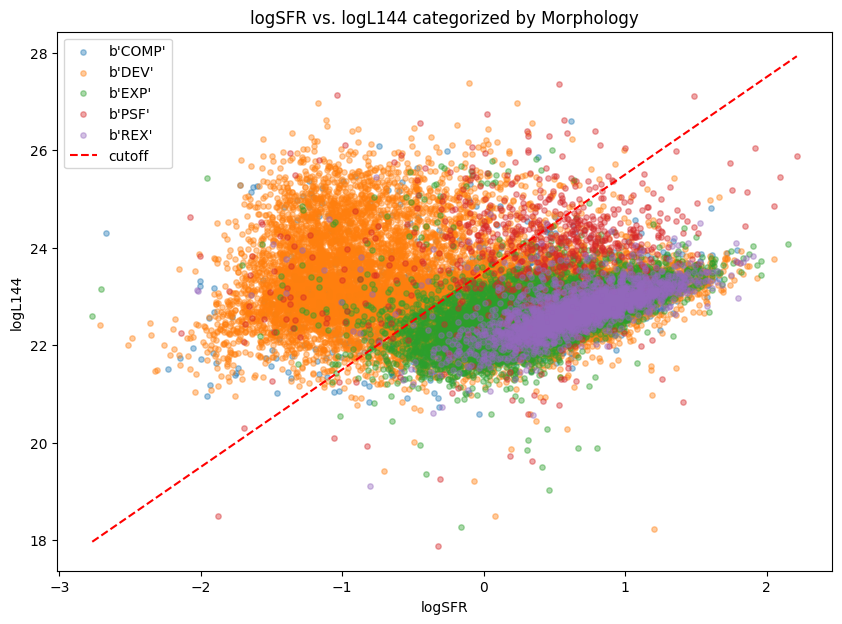

In [20]:
def SFG_AGN_cutoff_plot_preliminary_line(p1, p2, clean_table):
    """
    Plots two parameters with color-coding based on morphological type, with a cutoff line between linear scaling and AGN driven. 
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Handle NaN values to ensure polyfit and plotting work correctly
    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    data = clean_table[mask]

    # 2. np.unique returns the sorted unique elements of an array ---> PSF, REX, DEV, EXP, COMP
    morph_types = np.unique(data['Type'])
    for m_type in morph_types:
        type_mask = (data['Type'] == m_type) # filter through each type
        # if we run: mask = (data['Type'] == "DEV"), we get the butterfly figure as before. 
        ax.scatter(
            data[p1][type_mask],  # apply 'type' mask
            data[p2][type_mask], 
            label=m_type, 
            alpha=0.4,   # Transparency for overlapping points
            s=15         # Adjusted point size for clarity
        )


    '''CUTOFF LINE: done visually this time'''
    intercept = 23.5
    slope = 2

    x_fit = np.linspace(np.min(data[p1]), np.max(data[p1]), num=50)
    y_fit = x_fit * slope + intercept

    ax.plot(x_fit, y_fit, '--', color = 'r', label = "cutoff")
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f"{p1} vs. {p2} categorized by Morphology")
    # ax.legend(title="Morphology Type")
    #plt.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.show()

SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  clean_data) # cannot do this before clean data, because we wouldn't have L144 otherwise. 

## Apply cutoff using slope and intercept found in previous step

In [23]:
# Cutoff: 
''' Function compute_slope not really necessary for our case right now. 
def compute_slope_intercept(x1, x2, y1, y2):
    x1 = 0.880
    x2 = -0.324
    y1 = 27.65
    y2 = 26.27

    slope = (y2-y1) / (x2-x1)
    intercept = y1 - slope * x1

    return slope, intercept'''


def bool_cutoff_SFG(slope, intercept, data):
    '''
    Definition: Function that will cut off elements under the line that defines the SFG vs. AGN cutoff. 
    To do so, we need to filter out all elements with logL144 > y(logSFR)
    '''
    
    is_agn = data['logL144'] > (slope * data['logSFR'] + intercept)
    data['cutoff'] = is_agn
    # Here, True represents that the value is above the cutoff+ --> AGN in origin
    
    data.write('cutoff_table.fits', format='fits', overwrite=True)

    return data

def excess_radio_filter(data):
    excess_mask = np.where(data['cutoff']==True)
    return data[excess_mask]

def print_CR(data):
    '''
    Defn: Function to compute the contamination rate of a galaxy. 
    Population = "all elements that have type category" = len(data['Type']) 
    SFG = "star forming galaxies" = Morphology Type = REX or EXP
    '''
    Population = len(data)
    SFG = np.sum(data['Type'] == "REX") + np.sum(data['Type'] == "EXP") # Sum to get 'True' values in mask

    print(f"Contamination Rate = {SFG / float(Population) * 100 :.2f}%")


What we're doing here is create a new column labeled "cutoff", which is: 
- False if a row is consistent with SFG
- True if shows excess radio (above cutoff line) and therefore is AGN in origin

Yet, since most plots rely on examining only AGN data, we include the function "excess_radio_filter" to return a dataset with all data['cutoff'] == False filtered out. 

Successfully loaded 40476 sources from disk.
Contamination Rate = 3.59%


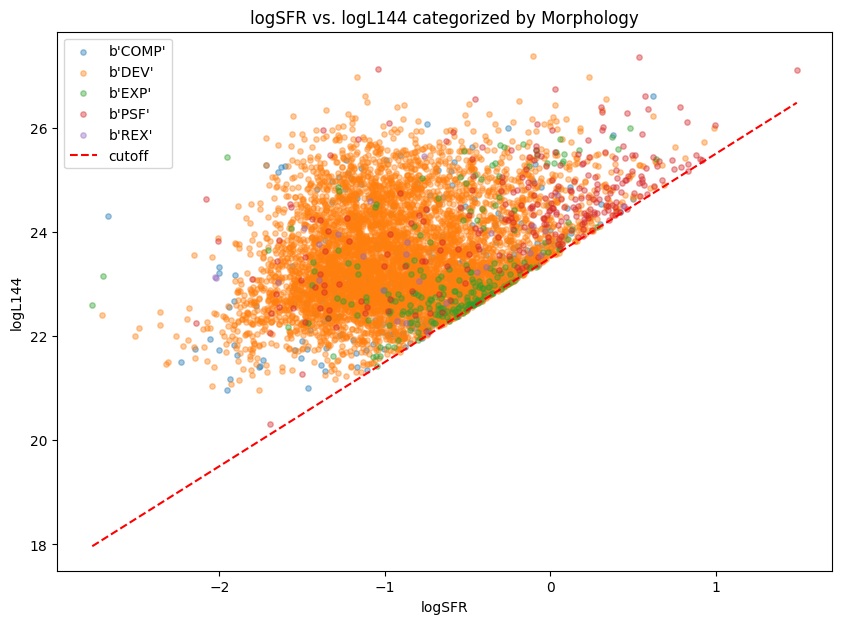

In [31]:
intercept = 23.5
slope = 2

clean_data = load_fits_table("clean_table.fits")

cut_data = bool_cutoff_SFG(slope, intercept, clean_data)
# Print also CR of data
print_CR(excess_radio_filter(cut_data))

#Check correctness of cut visually: 
SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  excess_radio_filter(cut_data))

# Plot DEV population vs. Redshift (rho vs. logL144)

## mass / rho vs. L144 

<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_111563/845332740.py:26: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


Successfully loaded 40476 sources from disk.


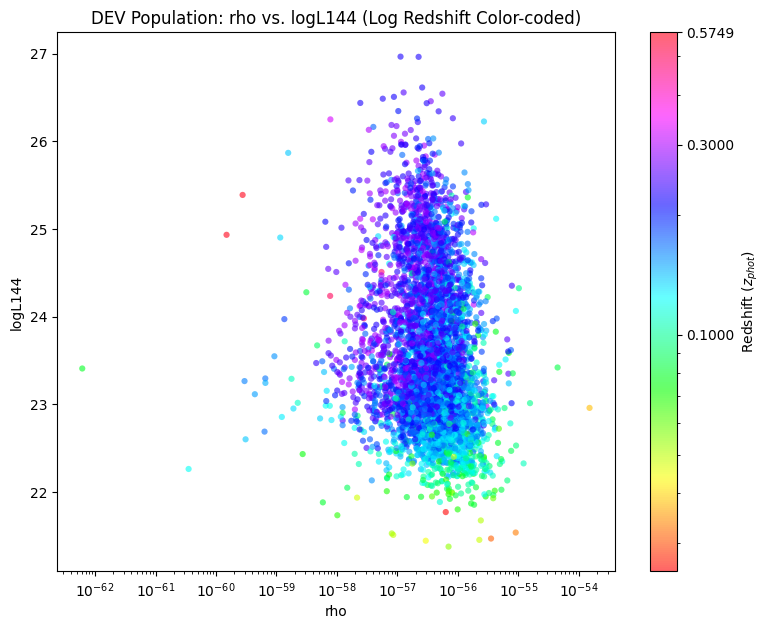

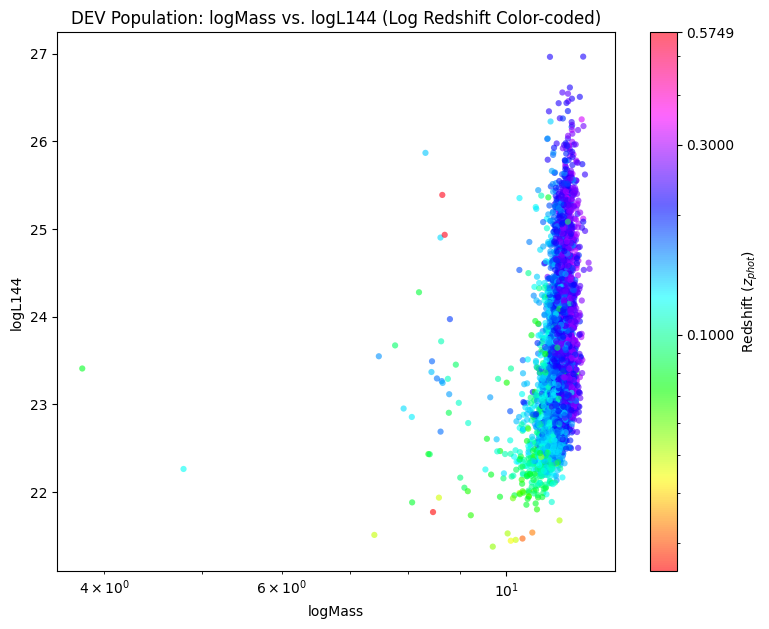

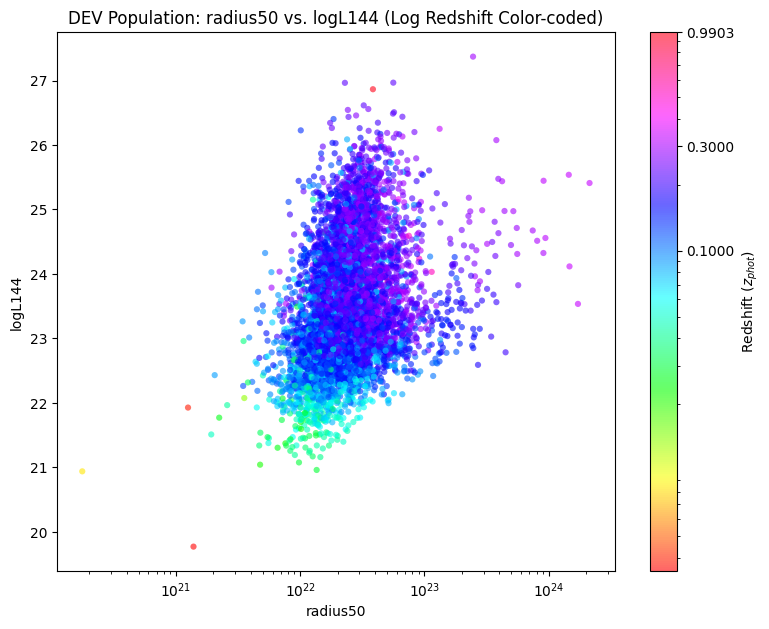

In [29]:
def zscale_plot_DEV(data_table, p1, p2):
    # 1. Filter for the DEV population only
    dev_mask = (data_table['Type'] == 'DEV')
    dev_data = data_table[dev_mask]
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(r'$\rho$ ($M_{\odot}$ / cm$^3$)')
    ax.set_ylabel('logL144 (dex W/Hz)')
    '''
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    
    ax.set_title(f'DEV Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.show()

cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_plot_DEV(excess_cut_data, 'rho', 'logL144')
zscale_plot_DEV(excess_cut_data, 'logMass', 'logL144')
zscale_plot_DEV(excess_cut_data, 'radius50', 'logL144')


#lotss_columns_parse = ['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass', 'Type', 'r50']


## Discussion of Plots
With these plots in hand, they are initially a shock. In this paper: https://ui.adsabs.harvard.edu/abs/2019A%26A...622A..12H/abstract , the authors point out that *radio luminoisty must depend strongly on the source age (since the lminosity depends on the energy density in the lobes, the lobe volume, [...], all of which evolve with time)*. The fact that we can observe this effect (most clear in 'mass vs. L144' plot) indicates that our selection of sources correctly parsed AGN galaxies. It is unclear here whether **jets or other AGN feedback drives radio emission** in these galaxies. 

The most troubling feature of the plots is that for small changes in rho, mass, radius50 (less pronounced) --> we obtain "enormous columns" where the luminosity in a given x-coordinate and redshift spans orders of magnitude in L144. This effect is most pronounced for zphot > 0.1. 

It looks like with increasing redshift the "pillar effect" (orders of magnitude of span) increases. It might be useful to plot a 2-D **histogram** of distinct redshift bins to see if this scaling is indeed present. ---> Plot: 
- sum of all luminosities in that bin (column effect)
- Average of luminosities in a given redshift bin (to find whether L144_avg scales with redshift)

Also, find relations NOT only of total luminosity, but rather distance from predicted (cutoff line). Remember we had: 
- intercept = 23.5
- slope = 2
- data['logL144'] > slope * data['logSFR'] + intercept ---> this was the line cutoff


Some possible explanations: 
- Jet Beaming factor ("fake" luminosity)
- AGN Cycles of Activity
- 

## Excess (cutoff) Luminsoty

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_111563/3033666961.py:33: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


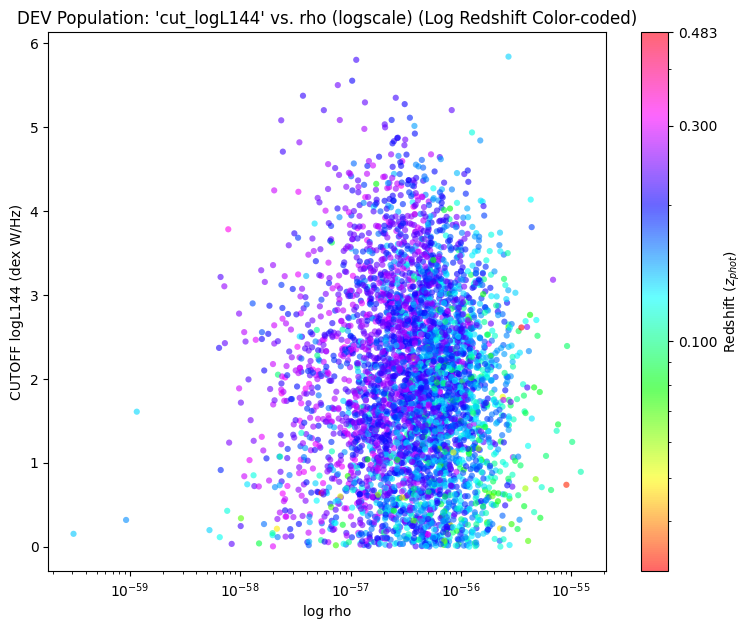

In [30]:
'''Implemented directly in code
def excess_luminosity(data, slope = 2, intercept = 23.5):
    logL_cutoff = data['logL144'] - (slope * data['logSFR'] + intercept)
    return logL_cutoff
'''

def plot_excess_rho_L144(data_table, param = 'rho', slope = 2, intercept = 23.5):
    dev_mask = (data_table['Type'] == 'DEV')
    dev_data = data_table[dev_mask]
    
    nan_mask = ~np.isnan(dev_data['logSFR']) & ~np.isnan(dev_data['logL144']) & ~np.isnan(dev_data[param])
    plot_data = dev_data[nan_mask]

    logL_cutoff = plot_data['logL144'] - (slope * plot_data['logSFR'] + intercept)

    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    sc = ax.scatter(
        plot_data[param], 
        logL_cutoff,
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(r'$\rho$ ($M_{\odot}$ / cm$^3$)')
    ax.set_xlabel('CUTOFF logL144 (dex W/Hz)')
    '''
    ax.set_ylabel('CUTOFF logL144 (dex W/Hz)')
    ax.set_xlabel(f"log {param}")
    
    ax.set_title(f"DEV Population: 'cut_logL144' vs. {param} (logscale) (Log Redshift Color-coded)")

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.show()

intercept = 23.5
slope = 2
plot_excess_rho_L144(excess_cut_data, 'rho', slope = 2, intercept = 23.5)


It is unclear what sorts of conclusions I should be able to extract from this plot. We see the colors more clearly divided here than in the non-cutoff plot. 

## Binning
In both cases (subsections) detailed below I will need to split the data into redshift bins. 

## Claire Suggestions: 
Awesome work with this and thanks for the update! I have a couple of suggestions for you: 

1) With the mass, since it's provided in log, you'll either want to plot the x-axis in linear or convert to actual mass. You'll see this dataset indeed has many orders of magnitude in mass. 
2) In general, I think it would be nice to see the difference between the AGN population and the non-AGN,  so on these plots I would suggest that you use the cutoff criterion you've created and plot two populations (rather than just DEV morphology). So that would be all those above the criteria versus all those below. Then we can answer science questions related to how the AGN population is different from the star forming galaxy population. 
3) I would guess that the authors of the article mean age of the AGN system, not age of the universe, when they suggest that the luminosity should depend on age. This would mean how long the black hole has been in an active phase. In general, at any redshift except super high z (i.e., z>12 or something), we can have both young and old galaxies--referring to their stellar populations. A good proxy of the AGN age might be the size of the radio emission? It looks like that's stored in the "Size" column. 



In [5]:
cut_table = load_fits_table("cutoff_table.fits")

Successfully loaded 7909 sources from disk.


### Convert logMass to actual mass

<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_111563/3923776963.py:26: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


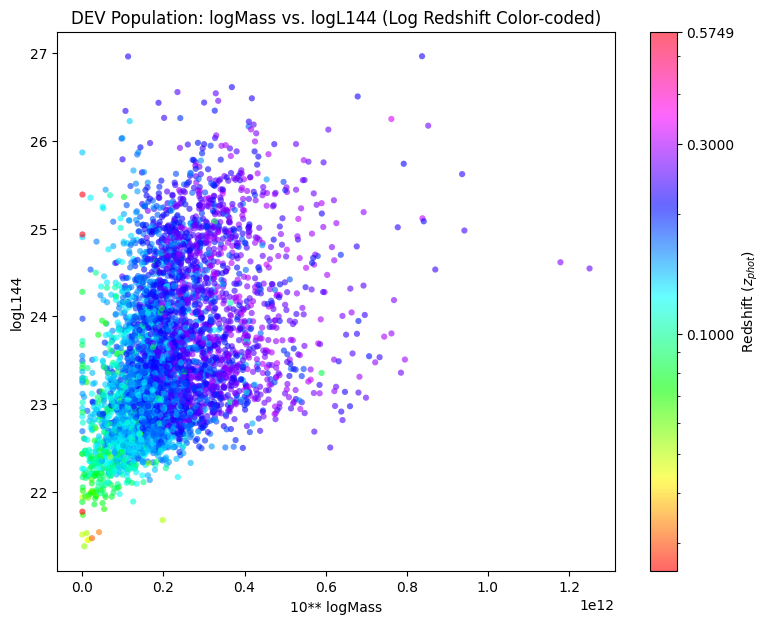

In [14]:
def mass_actual_zscale_plot_DEV(data_table, p1, p2):
    # 1. Filter for the DEV population only
    dev_mask = (data_table['Type'] == 'DEV')
    dev_data = data_table[dev_mask]
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    #ax.set_xscale('log')
    
    sc = ax.scatter(
        10 ** plot_data[p1], # plot actual mass 
        plot_data[p2], 
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(Mass '$(10^{M_{\odot})}$')
    ax.set_ylabel('logL144 (dex W/Hz)')
    '''
    
    #ax.set_xlabel(r'Mass ($10^{M_{\odot}}$)')    
    ax.set_xlabel(f"10** {p1}")
    ax.set_ylabel(p2)

    ax.set_title(f'DEV Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.show()

mass_actual_zscale_plot_DEV(cut_table, 'logMass', 'logL144')

From this plot we get masses between [1e11, 1e12] (Msun), which is consistent with average masses of galaxies. 

### AGN vs. SFG plots

We need to change some things: 
- Don't filter by population == DEV
- Plot populations above and below cutoff with different shapes (e.g. circle vs. rectangle) --> reserve color to zphot

#### Outdated: 

Successfully loaded 40476 sources from disk.


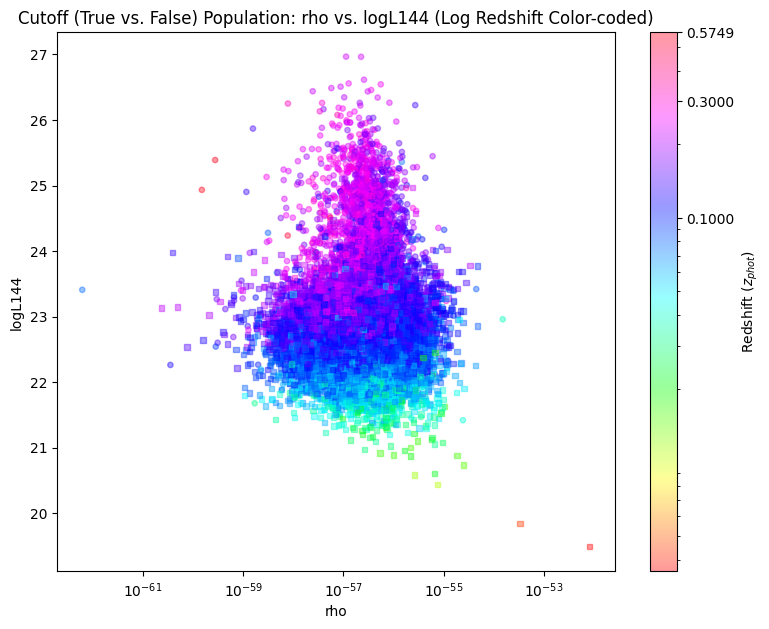

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f8d16f19800> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 900x700 with 2 Axes>

In [43]:
def SFG_AGN_zscale_plot_outdated(data, p1, p2):
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting --> include isnan zphot for colormap later
    nan_mask = ~np.isnan(data[p1]) & ~np.isnan(data[p2]) & ~np.isnan(data['zphot'])
    plot_data = data[nan_mask]

    # If no data to plot after filtering skip and print that. 
    if len(plot_data) == 0:
        print(f"Skipping plot: No valid data for {p1} vs {p2}")
        return
        
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    cmap = plt.get_cmap('hsv')
    norm = mcolors.LogNorm(
        vmin=plot_data['zphot'].min(), 
        vmax=plot_data['zphot'].max()
    )

    # Easier to use two distinct masks than the 'for loop' (for colobar especially)
    agn_mask = plot_data['cutoff'] == True
    sfg_mask = plot_data['cutoff'] == False

    sc1 = ax.scatter(
                plot_data[p1][agn_mask],  # apply 'type' mask
                plot_data[p2][agn_mask], 
                label="Above cut (AGN)", 
                marker = 'o',
                alpha=0.4,   # Transparency for overlapping points
                s=15,         # Adjusted point size for clarity
                c=plot_data['zphot'][agn_mask], # Filter the color data with the same mask!
                cmap=cmap,
                norm=norm,
            )

    sc2 = ax.scatter(
                plot_data[p1][sfg_mask],  # apply 'type' mask
                plot_data[p2][sfg_mask], 
                label="Below cut (SFG)", 
                marker = 's',
                alpha=0.4,   # Transparency for overlapping points
                s=15,         # Adjusted point size for clarity
                c=plot_data['zphot'][sfg_mask], # Filter the color data with the same mask!
                cmap=cmap,
                norm=norm,
            )

    
    # 5. Add labels and title
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    
    ax.set_title(f'Cutoff (True vs. False) Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    
    cbar = plt.colorbar(sc1, ticks=custom_ticks) # can use sc1 because it's linked to the same 'norm' as sc2.  

    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.show()

cut_data = load_fits_table("cutoff_table.fits")
SFG_AGN_zscale_plot_outdated(cut_data, 'rho', 'logL144')
SFG_AGN_zscale_plot_outdated(cut_data, 'logMass', 'logL144')
SFG_AGN_zscale_plot_outdated(cut_data, 'radius50', 'logL144')

Besides all the errors in the code, we see also that it's not very easy to distinguish the populations. Hence, we create a new plot (with the help of GEMINI) to plot two axes side by side, with the same scale and to prevent all these errors. 

#### GEMINI improved

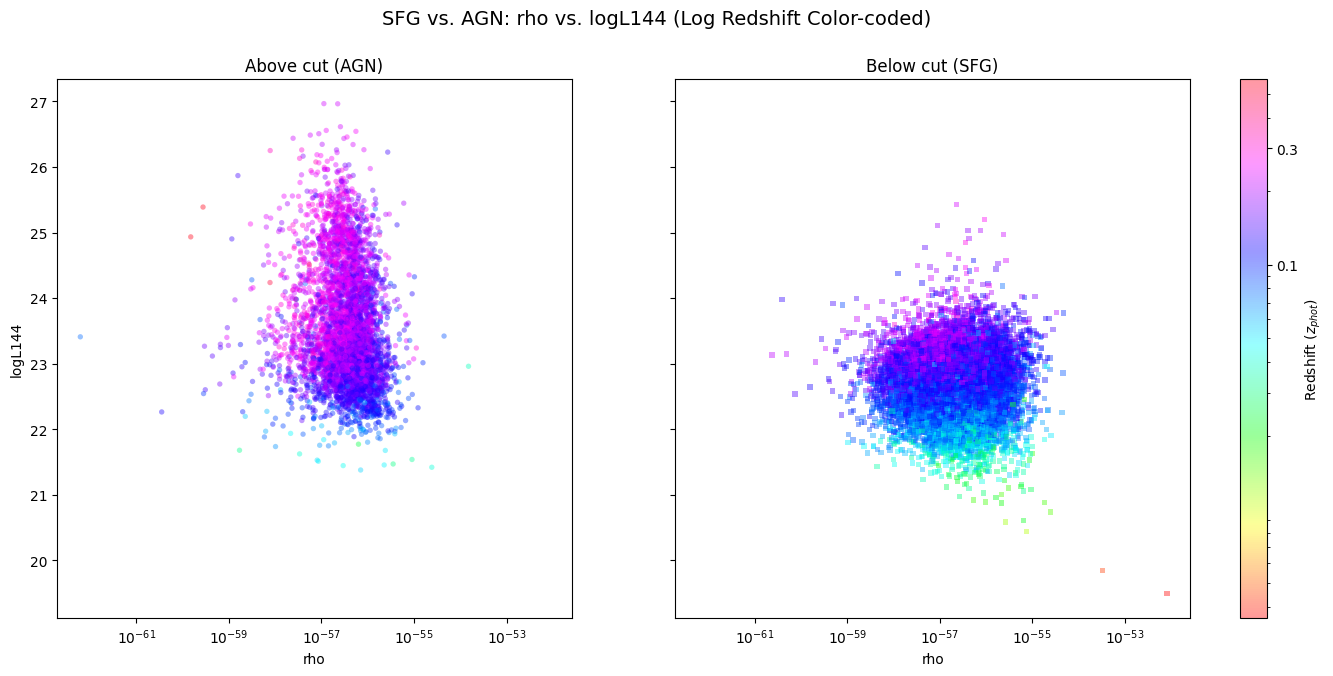

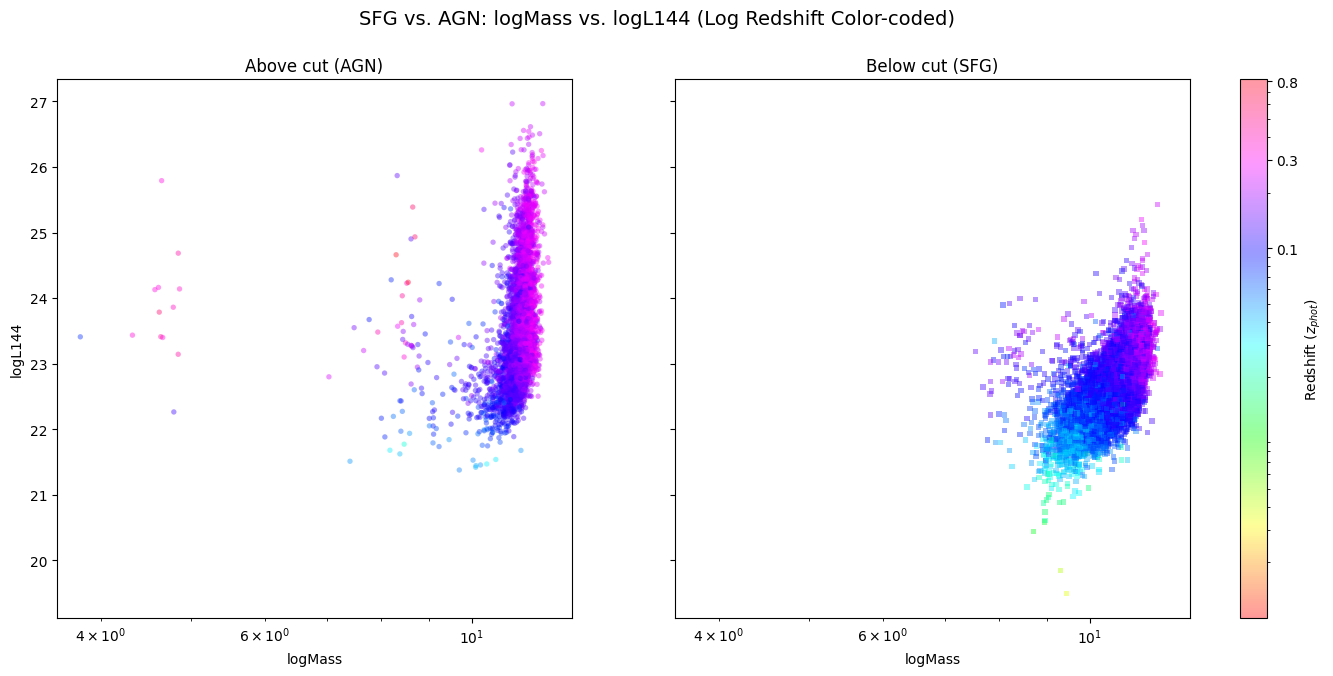

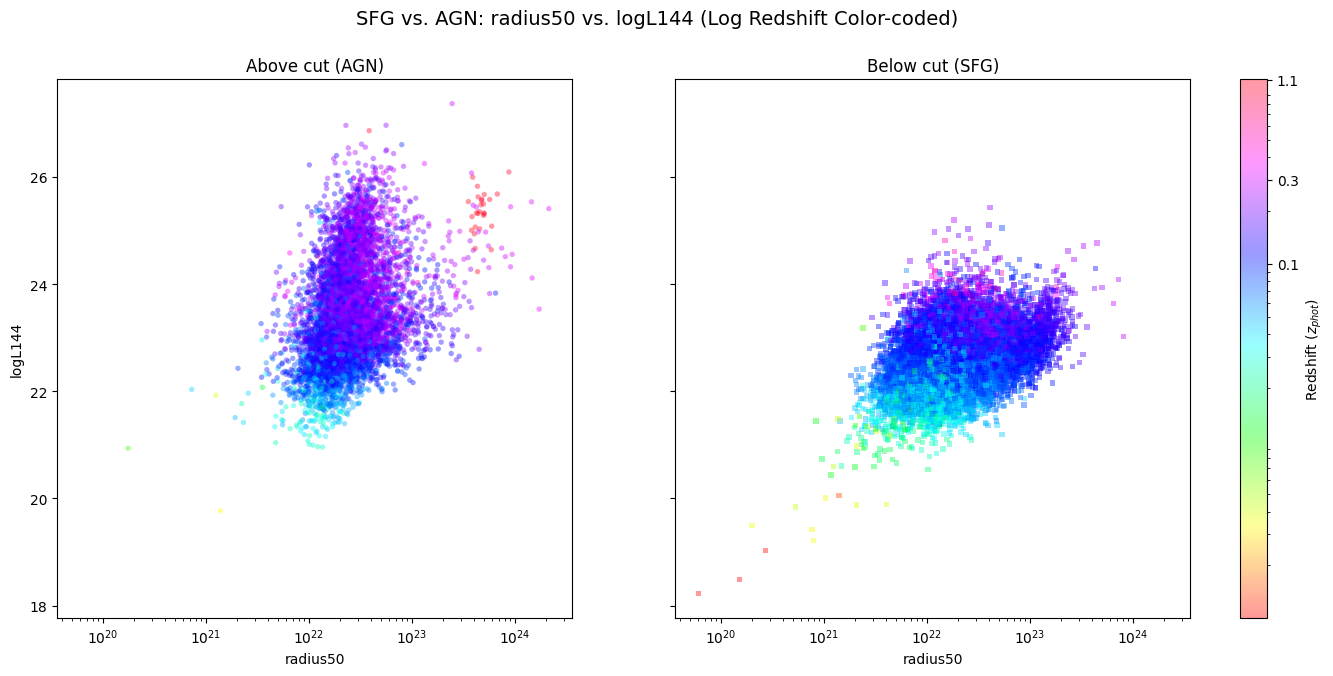

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np

def SFG_AGN_zscale_plot(data, p1, p2):
    # 1. Filter out NaNs for p1, p2, and zphot
    nan_mask = ~np.isnan(data[p1]) & ~np.isnan(data[p2]) & ~np.isnan(data['zphot'])
    plot_data = data[nan_mask]
    
    # Safety Check: If no data remains after filtering, skip plotting to avoid errors
    if len(plot_data) == 0:
        print(f"Skipping plot: No valid data for {p1} vs {p2}")
        return

    # 2. Setup Figure with 2 subplots side-by-side
    # sharex and sharey ensure both plots use the exact same scale for comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    
    # 3. Handle LogNorm and Colormap safely
    z_min = plot_data['zphot'].min()
    z_max = plot_data['zphot'].max()
    
    # LogNorm fails if vmin <= 0. Redshift should be > 0, but we force a tiny floor just in case.
    vmin_safe = max(z_min, 1e-3) 
    
    cmap = plt.get_cmap('hsv')
    norm = mcolors.LogNorm(vmin=vmin_safe, vmax=z_max)

    # 4. Create masks
    agn_mask = plot_data['cutoff'] == True
    sfg_mask = plot_data['cutoff'] == False

    # --- Plot 1: AGN (Left) ---
    sc1 = ax1.scatter(
        plot_data[p1][agn_mask],  
        plot_data[p2][agn_mask], 
        c=plot_data['zphot'][agn_mask],
        cmap=cmap,
        norm=norm,
        marker='o',
        alpha=0.4,
        s=15,
        edgecolors='none'
    )
    ax1.set_title("Above cut (AGN)")
    ax1.set_xscale('log')
    ax1.set_xlabel(p1)
    ax1.set_ylabel(p2)

    # --- Plot 2: SFG (Right) ---
    sc2 = ax2.scatter(
        plot_data[p1][sfg_mask],  
        plot_data[p2][sfg_mask], 
        c=plot_data['zphot'][sfg_mask],
        cmap=cmap,
        norm=norm,
        marker='s',
        alpha=0.4,
        s=15,
        edgecolors='none'
    )
    ax2.set_title("Below cut (SFG)")
    ax2.set_xscale('log')
    ax2.set_xlabel(p1)
    # y-label is hidden by default because sharey=True

    # 5. Global Formatting
    fig.suptitle(f'SFG vs. AGN: {p1} vs. {p2} (Log Redshift Color-coded)', fontsize=14)

    # 6. Shared Colorbar
    # Pass 'ax=[ax1, ax2]' to make the colorbar take space from both plots
    custom_ticks = [0.1, 0.3, round(z_max, 1)]
    cbar = fig.colorbar(sc1, ax=[ax1, ax2], ticks=custom_ticks, fraction=0.046, pad=0.04) 
    
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    cbar.set_label('Redshift ($z_{phot}$)')

    plt.show()

# Example usage:
SFG_AGN_zscale_plot(cut_data, 'rho', 'logL144')
SFG_AGN_zscale_plot(cut_data, 'logMass', 'logL144')
SFG_AGN_zscale_plot(cut_data, 'radius50', 'logL144')

The most obvious differnece is that: 
- In AGN we observe the "pillars" (big $\frac{\Delta L144}{\Delta radius50}$)
- In SFG we observe stripes, or horizontal lines: big $\frac{\Delta radius50}{\Delta L144}$

Moreover, for rho vs. logL144 we can even see a linear increase for ecah redshift, where higher radius50 implies higher logL144 in an approximately linear scaling. 

We also note that the SFG population is younger, showing warmer (orange / yellow) colors --> lower redshift (i.e. age), while AGN appear to be older, tending to higher redshift colors (dark blue and purple). This claim, though it should be analyzed with binning in more detail, appears to suggest an observational bias. 

### Binning


It looks like with increasing redshift the "pillar effect" (orders of magnitude of span) increases. It might be useful to plot a 2-D **histogram** of distinct redshift bins to see if this scaling is indeed present. ---> Plot: 
- sum of all luminosities in that bin (column effect)
- Average of luminosities in a given redshift bin (to find whether L144_avg scales with redshift)

To compute the distinct bins, what I should do is to: 
- create an np.linspace with N subdivisions correspoding to fractions between z_min and z_max
- Sum all of the logL144 in that bin --> then divide by no. elements (to get average)
- Plot x: zphot, y: avg logL144

In [6]:
cut_data = load_fits_table("cutoff_table.fits")
is_agn= (cut_data['cutoff'] == True)
cutoff_table = cut_data[is_agn]

Successfully loaded 40476 sources from disk.


In [53]:
def bin_zphot_logL144(unclean_data, num_bins=1000):
    nan_mask = ~np.isnan(unclean_data['logL144']) & ~np.isnan(unclean_data['zphot'])
    data = unclean_data[nan_mask]

    z_min = np.min(data['zphot'])
    z_max = np.max(data['zphot'])

    z_bins = np.linspace(z_min, z_max, num=num_bins) 
    luminosity_bins_values = np.array([])

    for i in range(len(z_bins)-1):
        z_min_i = z_bins[i]
        z_max_i = z_bins[i+1]

        z_mask_i = np.where((data['zphot'] > z_min_i) & (data['zphot'] < z_max_i))
        
        logL144_len_i = len(data[z_mask_i]['logL144'])
        logL144_sum_i = np.sum(data[z_mask_i]['logL144'])

        luminosity_bins_values = np.append(luminosity_bins_values, logL144_sum_i/float(logL144_len_i)) # unclear whether I should add float, but keep to prevent integer division
        
    return z_bins, luminosity_bins_values

bins, lumins = bin_zphot_logL144(cutoff_table)

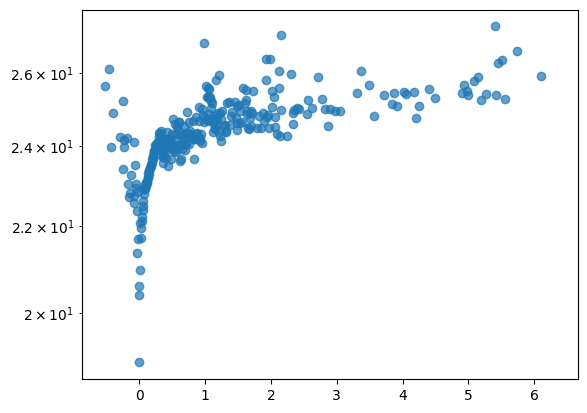

In [55]:
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.scatter(bin_centers, lumins, marker='o', alpha = 0.7, linestyle='-')
plt.yscale('log')